<a href="https://colab.research.google.com/github/sipark109/26MLseminar/blob/linear_regression/linear_regression_fffinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## linear regression : Insurance Charges
선형회귀 모델을 이용하여 보험비 분석하기

나이, 성별, 비만율, 자녀수, 흡연유무, 지역 등의 데이터로 청구되는 보험료 예측

* 모든 feature 사용한 경우
* feature selection 사용한 경우

두 가지 경우를 비교

사용한 데이터: https://www.kaggle.com/datasets/mirichoi0218/insurance

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import r2_score, mean_squared_error

In [2]:
df = pd.read_csv("insurance.csv")

In [3]:
df.head()
##데이터 어떻게 생겼는지 확인

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### 데이터 및 결측치 확인

In [4]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


결측치는 없지만 성별, 흡연유무, 지역 변수에 전처리가 필요함

### 전처리: 문자열을 숫자로 변환

sex, smoker는 값이 2개(male/female, yes/no)라 0/1로 변환하고,
region은 값이 4개라 원-핫 인코딩으로 변환한다.

원-핫 인코딩(One-Hot Encoding)을 하는 이유: region처럼 값이 4개인데 그냥 northeast=0,
northwest=1, southeast=2, southwest=3 이렇게 숫자를 매기면 모델이 숫자의
크기를 관계로 인식해버려서 (지역 이름 사이엔 그런 크기 순서가 없으니까 안 됨)

| region | region_northwest | region_southeast | region_southwest |
|---|---|---|---|
| northeast | 0 | 0 | 0 |
| northwest | 1 | 0 | 0 |
| southeast | 0 | 1 | 0 |
| southwest | 0 | 0 | 1 |

 전부 0이면 자동으로 northeast라는 뜻이 되기 때문에, 나머지 하나는
굳이 만들지 않아도 정보가 전부 담긴다.

In [5]:
df["sex"] = df["sex"].map({
    "male": 1,
    "female": 0
})

df["smoker"] = df["smoker"].map({
    "yes": 1,
    "no": 0
})

df = pd.get_dummies(df, columns=["region"], drop_first=True)

In [6]:
df.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,False,False,True
1,18,1,33.770,1,0,1725.55230,False,True,False
2,28,1,33.000,3,0,4449.46200,False,True,False
3,33,1,22.705,0,0,21984.47061,True,False,False
4,32,1,28.880,0,0,3866.85520,True,False,False


### x(feature), y(target) 분리

y는 보험료임

In [7]:
X = df.drop("charges", axis=1)

y = df["charges"]

### Train / Test 분리

80 / 20

80%는training set, 나머지 20%는 test set으로 최종 성능 평가에만 사용한다.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### 1. Baseline: 모든 feature 사용

feature selection을 하기 전에, 먼저 모든 feature를 다 사용한 모델을 baseline으로
만들어서 나중에 feature selection한 것과 비교한다.

In [9]:
baseline_model = LinearRegression()

baseline_model.fit(X_train, y_train)

LinearRegression()

In [10]:
baseline_pred = baseline_model.predict(X_test)

print("[Baseline] R² :", r2_score(y_test, baseline_pred))
print("[Baseline] MSE :", mean_squared_error(y_test, baseline_pred))

[Baseline] R² : 0.7835929767120723
[Baseline] MSE : 33596915.85136146


### 2. Feature Selection 진행

Forward Stepwise Selection으로 3개 feature만 선택



feature selection할때 training set만을 가지고 해야한다.

test set의 정보가 조금이라도 들어가면 데이터누수(data leakage) 생김<- test set에서 나온 성능이 실제보다 더 좋게 나올 수 있음

In [11]:
lr = LinearRegression()

sfs = SequentialFeatureSelector(
    lr,
    n_features_to_select=3,
    direction="forward"
)

sfs.fit(X_train, y_train)

selected_features = X_train.columns[sfs.get_support()]

print("Selected Features:")
print(selected_features)

Selected Features:
Index(['age', 'bmi', 'smoker'], dtype='object')


In [12]:
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

선택된 feature만 가지고 학습 진행

In [13]:
selected_model = LinearRegression()

selected_model.fit(X_train_selected, y_train)

LinearRegression()

In [14]:
selected_pred = selected_model.predict(X_test_selected)

print("[Feature Selection] R² :", r2_score(y_test, selected_pred))
print("[Feature Selection] MSE :", mean_squared_error(y_test, selected_pred))

[Feature Selection] R² : 0.7776932310583374
[Feature Selection] MSE : 34512843.8802279


## 모델 성능 평가

모델이 얼마나 정확하게 예측했는지 R², MSE로 비교한다.

* R² : 1에 가까울수록 모델이 데이터를 잘 설명함
* MSE : 평균제곱오차 (작을수록 좋음)

In [15]:
comparison = pd.DataFrame({
    "Model": ["Baseline (전체 6개 feature)", "Feature Selection (3개 feature)"],
    "R2": [r2_score(y_test, baseline_pred), r2_score(y_test, selected_pred)],
    "MSE": [mean_squared_error(y_test, baseline_pred), mean_squared_error(y_test, selected_pred)],
})
comparison

,Model,R2,MSE
0,Baseline (전체 6개 feature),0.783593,3.359692e+07
1,Feature Selection (3개 feature),0.777693,3.451284e+07


feature 6개를 3개로 줄였는데도 R²와 MSE가 거의 그대로다. 즉 빠진 3개 feature
(sex, children, region)는 보험료 예측에 미치는 영향이 거의 없었다는 뜻이고,
feature selection이 모델을 더 단순하게 만들면서도 성능 손실이 거의 없었다는 걸
확인할 수 있다.

### 예측 결과 시각화

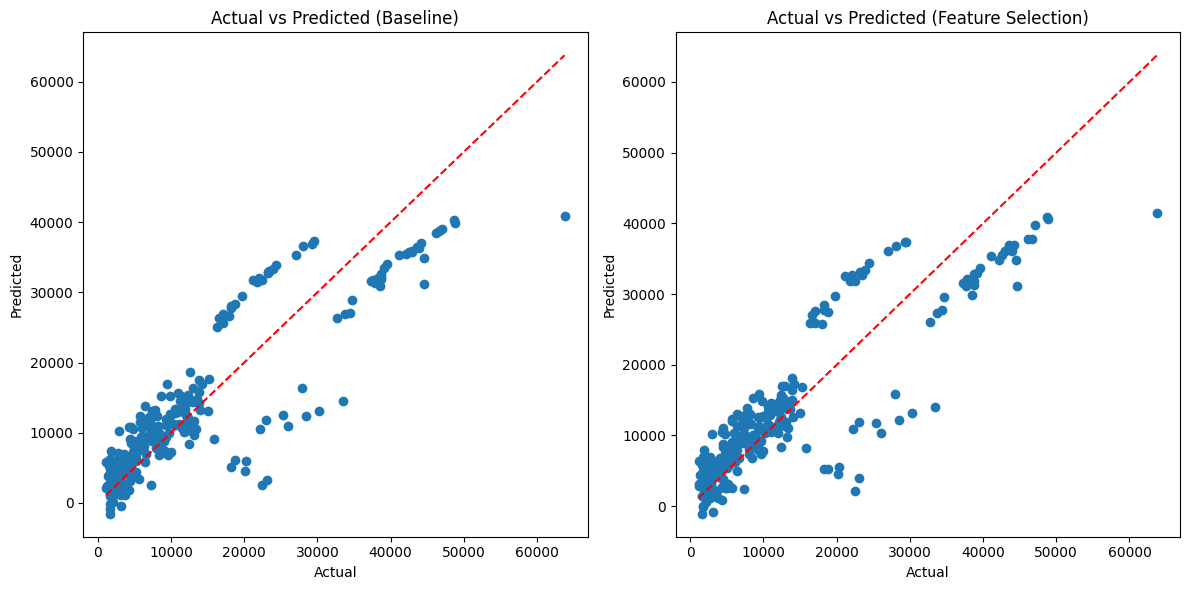

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].scatter(y_test, baseline_pred)
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'r--')
axes[0].set_xlabel("Actual")
axes[0].set_ylabel("Predicted")
axes[0].set_title("Actual vs Predicted (Baseline)")

axes[1].scatter(y_test, selected_pred)
axes[1].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'r--')
axes[1].set_xlabel("Actual")
axes[1].set_ylabel("Predicted")
axes[1].set_title("Actual vs Predicted (Feature Selection)")

plt.tight_layout()
plt.show()

x축: 실제 보험료

y축: 모델이 예측한 보험료

빨간색 점선: 실제값 = 예측값일 때의 선

* 점> 선: 실제보다 더 높게 예측(과대예측)
* 점==선: 실제 = 예측
* 점< 선: 실제보다 더 낮게 예측(과소예측)

## 결론

- Baseline(전체 6개 feature)과 Feature Selection(3개 feature: age, bmi, smoker)
  모델의 성능을 비교한 결과, feature를 절반으로 줄였음에도 R², MSE 차이가 크지
  않았다. 즉 sex, children, region은 보험료 예측에 미치는 영향이 크지 않았고,
  더 적은 정보만으로도 비슷한 예측력을 얻을 수 있음을 확인했다.
- **한계**: 이는 흡연과 BMI 같은 변수들의 **비선형적인 상호작용**을 선형회귀가 잡아내지
못하기 때문으로 보인다.상호작용 항(interaction term)을 추가하면 성능을
더 개선할 수 있을 것으로 예상된다.